In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [5]:
RESULTS_DIR = Path("results")

data = torch.load(RESULTS_DIR / "nnconv_predictions.pt")

preds = data["preds"]
targets = data["targets"]
positions = data["positions"]

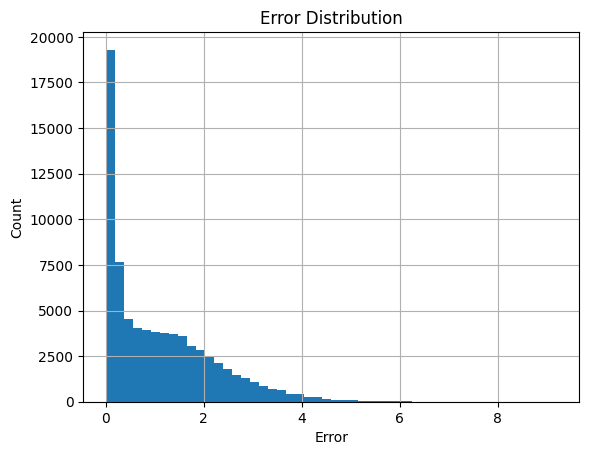

In [6]:
errors = torch.norm(preds - targets, dim=1)
os.makedirs("plots", exist_ok=True)
plt.figure()
plt.hist(errors.numpy(), bins=50)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Count")
plt.grid()
plt.savefig("plots/error_hist.png", dpi=200)
plt.show()

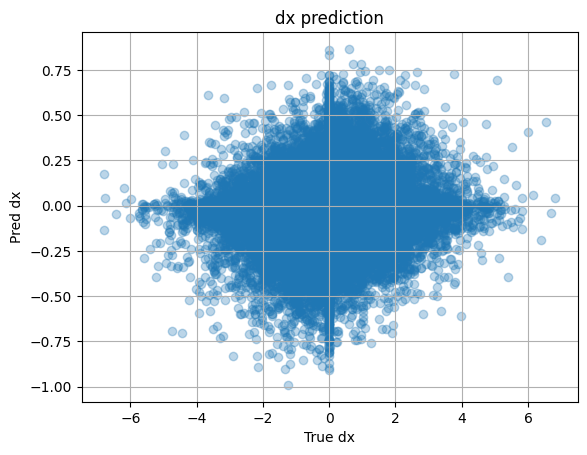

In [7]:
plt.figure()
plt.scatter(targets[:, 0], preds[:, 0], alpha=0.3)
plt.xlabel("True dx")
plt.ylabel("Pred dx")
plt.title("dx prediction")
plt.grid()
plt.savefig("plots/dx_scatter.png", dpi=200)
plt.show()

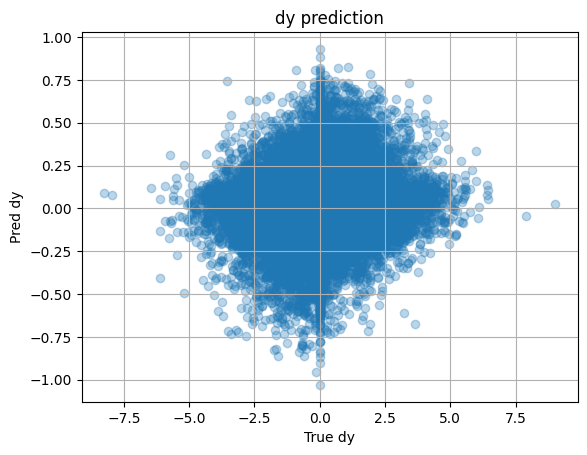

In [8]:
plt.figure()
plt.scatter(targets[:, 1], preds[:, 1], alpha=0.3)
plt.xlabel("True dy")
plt.ylabel("Pred dy")
plt.title("dy prediction")
plt.grid()
plt.savefig("plots/dy_scatter.png", dpi=200)
plt.show()

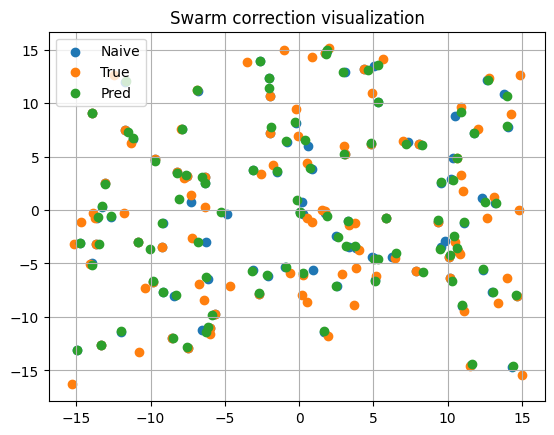

In [9]:
n = min(100, positions.shape[0])

naive = positions[:n]
true = positions[:n] + targets[:n]
pred = positions[:n] + preds[:n]

plt.figure()
plt.scatter(naive[:, 0], naive[:, 1], label="Naive")
plt.scatter(true[:, 0], true[:, 1], label="True")
plt.scatter(pred[:, 0], pred[:, 1], label="Pred")
plt.legend()
plt.title("Swarm correction visualization")
plt.grid()
plt.savefig("plots/trajectory.png", dpi=200)
plt.show()

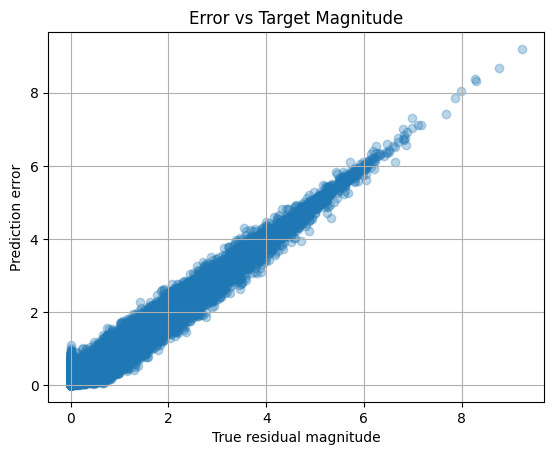

In [10]:
target_norm = torch.norm(targets, dim=1)

plt.figure()
plt.scatter(target_norm.numpy(), errors.numpy(), alpha=0.3)
plt.xlabel("True residual magnitude")
plt.ylabel("Prediction error")
plt.title("Error vs Target Magnitude")
plt.grid()
plt.savefig("plots/error_vs_magnitude.png", dpi=200)
plt.show()

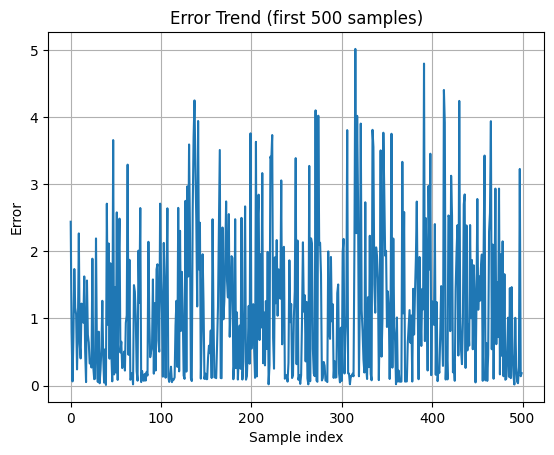

In [11]:
plt.figure()
plt.plot(errors[:500].numpy())
plt.xlabel("Sample index")
plt.ylabel("Error")
plt.title("Error Trend (first 500 samples)")
plt.grid()
plt.savefig("plots/error_trend.png", dpi=200)
plt.show()

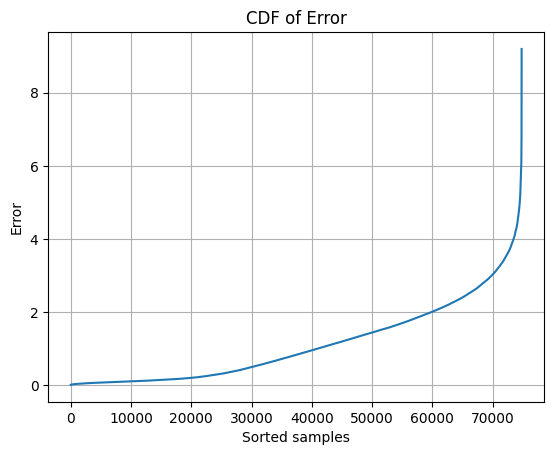

In [12]:
sorted_err = torch.sort(errors)[0]

plt.figure()
plt.plot(sorted_err.numpy())
plt.xlabel("Sorted samples")
plt.ylabel("Error")
plt.title("CDF of Error")
plt.grid()
plt.savefig("plots/error_cdf.png", dpi=200)
plt.show()